(C) 2025 Gerold Baier, University College London

# Two Nonlinear Two-Population Oscillators with Perturbation
## Model

The two populations' temporal dynamics (change of state) is described by two first-order nonlinear differential equations. Here we have two coupled units:

$$ \frac{dEx_1}{dt}      = (h_{ex}      - Ex_1    - c_2*sigmoid(In_1) + c_{EE}*sigmoid((Ex_1 + 
frac_E*Ex_2))  + pert)*\tau_{ex}$$
$$ \frac{dIn_1}{dt} \,\, = (h_{in} \,\, - In_1 \, - c_4*sigmoid(In_1) + c_{EI}*sigmoid((Ex_1 + 
frac_I*Ex_2)))*\tau_{in}$$

$$ \frac{dEx_2}{dt}      = (h_{ex}      - Ex_2    - c_2*sigmoid(In_2) + c_{EE}*sigmoid((Ex_2 + 
frac_E*Ex_1)))*\tau_{ex}$$
$$ \frac{dIn_2}{dt} \,\, = (h_{in} \,\, - In_2 \, - c_4*sigmoid(In_2) + c_{EI}*sigmoid((Ex_2 + 
frac_I*Ex_1)))*\tau_{in}$$

$Ex_i$ and $In_i$ are variables that change with time $t$ and represent the excitatory and inhibitory population, respectively.

$h_{ex}$ and $h_{in}$ are constant inputs to the populations. 

$c_2$ and $c_4$ are model parameters representing internal inhibitory coupling. 

$\tau_{ex}$ and $\tau_{in}$ are the poulation time constants.

$c_{EE}$ and $c_{EI}$ are self- and between population excitatory coupling parameters.

_pert_ represents external perturbation.

Function _sigmoid_ is a continuous step function, conmputationally implemented as tangens hyperbolicus.


In [1]:
from scipy.integrate import odeint, solve_ivp

import sk_dsp_comm.sigsys as ss

from numpy import tanh, mod, linspace, around, zeros, mod, asarray
from numpy import sin, pi, var, ndarray, flip, arange, sign

from numpy.random import default_rng, seed

from matplotlib.pyplot import subplots


from scipy.signal import find_peaks

from itertools import product

from models import two_oscillators



# Functions

In [2]:

def plot_bifdiagram(results_min_f, results_max_f, 
                    par_set):
    
    N = len(results_min_f)

    fig, ax = subplots(nrows=2, figsize=(5, 4))

    for index in (0, 1):

        for xe, ye in zip(par_set, results_max_f[index]):
    
            if not isinstance(ye, ndarray):
                ax[index].scatter(xe, ye, c='r', s=6, marker='D')
            else:
                ax[index].scatter([xe] * len(ye), ye, s=3, c='k', marker='D')
    
        for xe, ye in zip(par_set, results_min_f[index]):
    
            if not isinstance(ye, ndarray):
                ax[index].scatter(xe, ye, c='r', s=6, marker='d')
            else:
                ax[index].scatter([xe] * len(ye), ye, s=3, c='gray', marker='d')
    
    
        ax[index].set_xticks(linspace(par_set[0], par_set[-1], 5));
        ax[index].set_xticklabels(around(linspace(par_set[0], par_set[-1], 5), 2), fontsize=16);
    
        ax[index].set_ylabel(f'EX_{index+1}', fontsize=14)
    
        y_min, y_max = ax[0].get_ylim()

        ax[index].set_ylim(y_min, y_max)
        ax[index].set_yticks(linspace(y_min, y_max, 3));
        ax[index].set_yticklabels(around(linspace(y_min, y_max, 3),2), fontsize=14);
        
    ax[1].set_xlabel('Parameter', fontsize=16)


    fig.tight_layout()
    
    return fig, ax

# Time Series

h_ex_0 = -6.9, h_in_0 = -4.0, frac_E, frac_I = 0.25, 0.00 

h_ex_0 = -6.95, h_in_0 = -4.0, frac_E, frac_I = 0.2, 0.00 

h_ex_0 = -6.95, h_in_0 = -4.0, frac_E, frac_I = 0.15, 0.00 

h_ex_0 = -7.0,  h_in_0 = -4.0, frac_E, frac_I = 0.2, 0.10

End of run: [ 0.38 -7.21  0.57 -6.35]



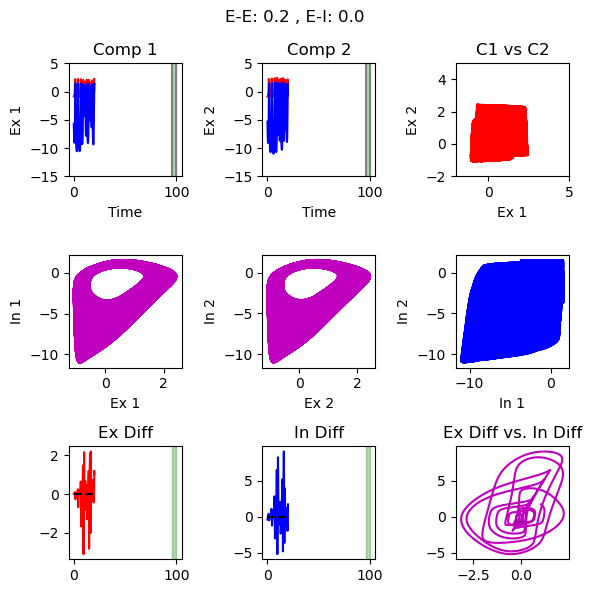

In [21]:
# Input parameter
h_ex_0 = -6.72
h_in_0 = -4.0

# Oscillator parameters
pars = (1, 2.5, 10, 0, 5, 10) # Homoclinic
# pars = (1, 1.5, 10, 0, 5, 10) # SNIC
# t_ex, t_in, c2, c4, cc_EE, cc_EI

# Oscillator coupling
frac_E, frac_I = 0.2, 0. # 0: no coupling

# Initial conditions
SEED = 8888
rng  = default_rng(SEED)
# y_ini = rng.uniform(size=4)
# y_ini = [ -1.9, -13.56, -1.9, -13.56]

# Time array
time_stop = 1000
sr        = 1000
time      = linspace(start=0, stop=time_stop, num=time_stop*sr)

rows = time.size

pulse_wid = 4.
pulse_amp = 0.
pulse_per = 10

pert = h_ex_0 + pulse_amp*ss.rect(mod(time, pulse_per)-(pulse_per)/2+pulse_wid/2, pulse_wid)


# Simulation
solution = solve_ivp(fun=two_oscillators, t_span=(0, time_stop), y0=y_ini, t_eval=time,
              args=(h_ex_0, h_in_0, pars, frac_E, frac_I, sr, time_stop, pert), 
              method='BDF', max_step=0.1)

t, y_pert = solution.t, solution.y.T

# Resetting of initial conditions
y_ini = y_pert[-1, :]

# Show final values of all variables
print('End of run:', around(y_pert[-1,:],2))
print('')

start, end = 0, 20000

fig, ax = subplots(ncols=3, nrows=3, figsize=(6, 6))

ax[0, 0].plot(time[start:end], y_pert[start:end,0], color='r');
ax[0, 1].plot(time[start:end], y_pert[start:end,2], color='r');
ax[0, 0].plot(time[start:end], y_pert[start:end,1], color='b');
ax[0, 1].plot(time[start:end], y_pert[start:end,3], color='b');

ax[1, 0].plot(y_pert[:,0], y_pert[:,1], color='m');
ax[1, 1].plot(y_pert[:,2], y_pert[:,3], color='m');
ax[1, 0].scatter(y_pert[-1,0], y_pert[-1,1], color='k')
ax[1, 1].scatter(y_pert[-1,2], y_pert[-1,3], color='k')

ax[0, 2].plot(y_pert[:,0], y_pert[:,2], color='r');
ax[0, 2].scatter(y_pert[-1,0], y_pert[-1,2], color='k')

ax[1, 2].plot(y_pert[:,1], y_pert[:,3], color='b');
ax[1, 2].scatter(y_pert[-1,1], y_pert[-1,3], color='k')


ax[0, 0].set_title('Comp 1')
ax[0, 1].set_title('Comp 2')
ax[0, 2].set_title('C1 vs C2')

ax[0, 0].set_xlabel('Time')
ax[0, 0].set_ylabel('Ex 1')
ax[1, 0].set_xlabel('Ex 1')
ax[1, 0].set_ylabel('In 1')
ax[0, 1].set_xlabel('Time')
ax[0, 1].set_ylabel('Ex 2')
ax[1, 1].set_xlabel('Ex 2')
ax[1, 1].set_ylabel('In 2')

ax[0, 2].set_xlabel('Ex 1')
ax[0, 2].set_ylabel('Ex 2')
ax[1, 2].set_xlabel('In 1')
ax[1, 2].set_ylabel('In 2')


ax[0, 0].set_ylim(-15, 5)
ax[0, 0].vlines(100-pulse_wid, -15, 5, color='gray')
ax[0, 0].vlines(100, -15, 5, color='gray')
ax[0, 0].fill_between([100-pulse_wid, 100], 0, 1, color='green', alpha=0.3, transform=ax[0, 0].get_xaxis_transform())

ax[0, 1].set_ylim(-15, 5)
ax[0, 1].vlines(100-pulse_wid, -15, 5, color='gray')
ax[0, 1].vlines(100, -15, 5, color='gray')
ax[0, 1].fill_between([100-pulse_wid, 100], 0, 1, color='green', alpha=0.3, transform=ax[0, 1].get_xaxis_transform())

ax[0, 2].set_xlim(-2, 5)
ax[0, 2].set_ylim(-2, 5)


ax[2, 0].plot(time[start:end], y_pert[start:end,0]-y_pert[start:end,2], color='r');
ax[2, 0].hlines(0, start//sr, end//sr, linestyle='--', color='k')
ax[2, 0].set_title('Ex Diff')
ax[2, 0].fill_between([100-pulse_wid, 100], 0, 1, color='green', alpha=0.3, transform=ax[2, 0].get_xaxis_transform())

ax[2, 1].plot(time[start:end], y_pert[start:end,1]-y_pert[start:end,3], color='b');
ax[2, 1].hlines(0, start//sr, end//sr, linestyle='--', color='k')
ax[2, 1].set_title('In Diff')
ax[2, 1].fill_between([100-pulse_wid, 100], 0, 1, color='green', alpha=0.3, transform=ax[2, 1].get_xaxis_transform())

ax[2, 2].plot(y_pert[start:end,0]-y_pert[start:end,2], y_pert[start:end,1]-y_pert[start:end,3], color='m');
ax[2, 2].scatter(y_pert[-1,0]    -y_pert[-1,2],        y_pert[-1,1]       -y_pert[-1,3], color='k')
ax[2, 2].set_title('Ex Diff vs. In Diff')

    
fig.suptitle(f'E-E: {frac_E} , E-I: {frac_I}')
    
fig.tight_layout()

(1000000, 4)

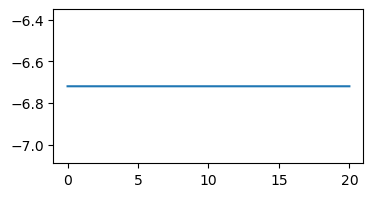

In [22]:
fig, ax = subplots(figsize=(4, 2))

ax.plot(time[:end], pert[:end])

y_pert.shape

In [23]:
y_pert.shape

(1000000, 4)

# Get maxima

In [24]:
results_series_max      = list()
results_series_max_inds = list()

chan_select = 1

series = y_pert[:, chan_select]

y_f_max_inds = find_peaks(series, distance=100)

ddata = zeros((len(y_f_max_inds[0]), 4))

for index in arange(4):

    ddata[:, index] = y_pert[y_f_max_inds[0], index]

ddata.shape

(571, 4)

In [30]:
y_f_max_inds[0].size

571

In [33]:
from numpy import diff

return_times = diff(y_f_max_inds[0])

return_times[:5]

array([2740, 2844, 2194,  912,  899])

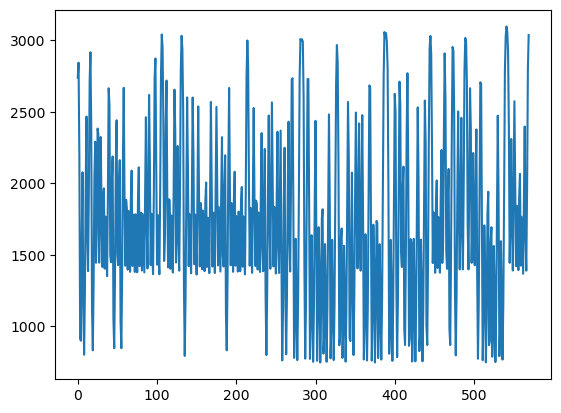

In [34]:
fig, ax = subplots()

ax.plot(return_times);

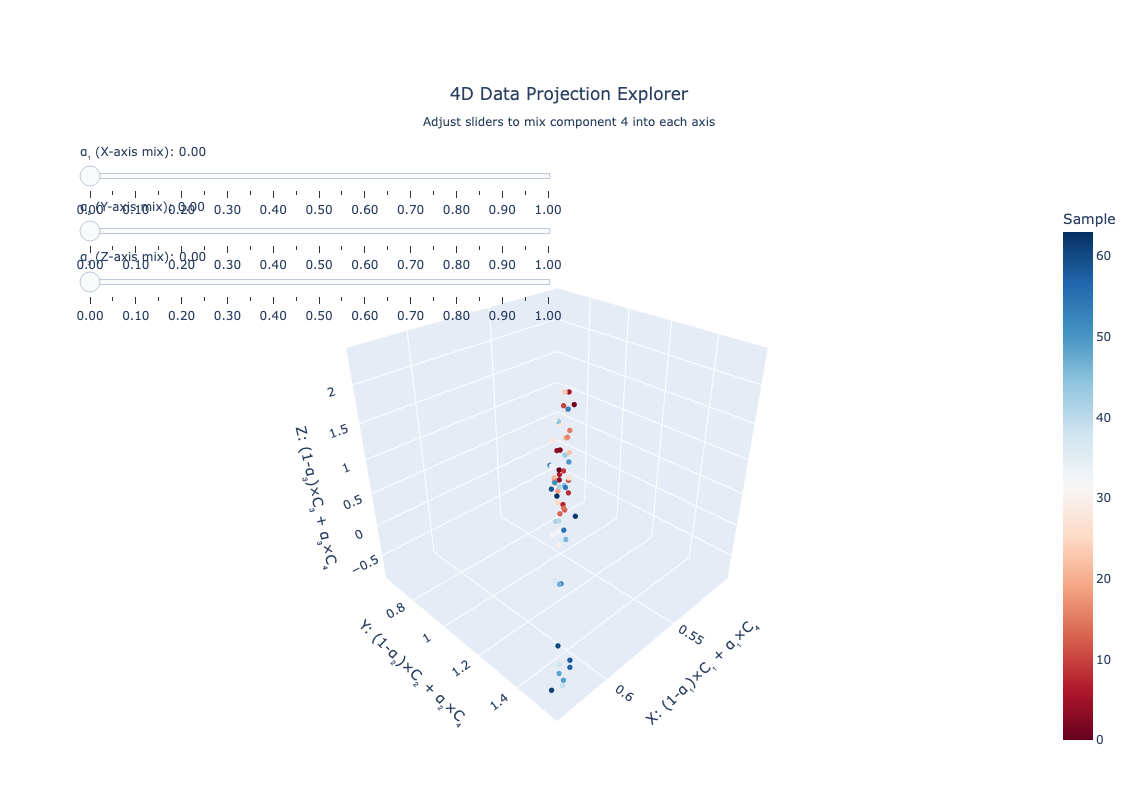

Interactive 4D projection explorer saved!

How to use:
- α=0: Shows original component on that axis
- α=1: Shows component 4 on that axis
- α∈(0,1): Linear interpolation between the two

Adjust the three sliders independently to explore different 3D projections of your 4D data.


In [20]:
import numpy as np
import plotly.graph_objects as go

# # Generate example 4D data (samples, 4)
# # Replace this with your actual data
# np.random.seed(42)
# n_samples = 500
# data = np.random.randn(n_samples, 4)

# # Add some structure to make it interesting
# t = np.linspace(0, 4*np.pi, n_samples)
# data[:, 0] = np.cos(t) + 0.3*np.random.randn(n_samples)
# data[:, 1] = np.sin(t) + 0.3*np.random.randn(n_samples)
# data[:, 2] = t/10 + 0.2*np.random.randn(n_samples)
# data[:, 3] = np.cos(2*t) + 0.3*np.random.randn(n_samples)

n_samples = ddata.shape[0]

# Extract components
c1, c2, c3, c4 = ddata[:, 0], ddata[:, 1], ddata[:, 2], ddata[:, 3]

# Create frames for different slider combinations
n_steps = 21  # Number of steps for each slider (0.0 to 1.0 in steps of 0.05)
alphas = np.linspace(0, 1, n_steps)

# We'll create frames for each combination of the three sliders
# For efficiency, we'll pre-compute key combinations and use sliders to select them
frames = []
frame_data = []

# Generate a reasonable subset of combinations
# Full grid would be 21^3 = 9261 frames which is too many
# Instead, we'll use the sliders to update via traces
for i, a1 in enumerate(alphas):
    for j, a2 in enumerate(alphas):
        for k, a3 in enumerate(alphas):
            # Calculate projected values
            val_1 = (1 - a1) * c1 + a1 * c4
            val_2 = (1 - a2) * c2 + a2 * c4
            val_3 = (1 - a3) * c3 + a3 * c4
            
            frame_name = f"a1_{i}_a2_{j}_a3_{k}"
            frame_data.append({
                'name': frame_name,
                'x': val_1,
                'y': val_2,
                'z': val_3,
                'a1': a1,
                'a2': a2,
                'a3': a3
            })

# Create initial plot (a1=a2=a3=0, showing components 1,2,3)
initial_x = c1
initial_y = c2
initial_z = c3

fig = go.Figure()

# Add the scatter trace
fig.add_trace(go.Scatter3d(
    x=initial_x,
    y=initial_y,
    z=initial_z,
    mode='markers',
    marker=dict(
        size=3,
        color=np.arange(n_samples),  # Color by sample index
        colorscale='RdBu',
        showscale=True,
        colorbar=dict(title="Sample")
    ),
    name='4D Projection'
))

# Create slider steps for each of the three parameters
steps_a1 = []
steps_a2 = []
steps_a3 = []

# Generate all combinations for the sliders
for i, a1 in enumerate(alphas):
    val_1 = (1 - a1) * c1 + a1 * c4
    steps_a1.append(dict(
        method="restyle",
        args=[{"x": [val_1]}, [0]],
        label=f"{a1:.2f}"
    ))

for j, a2 in enumerate(alphas):
    val_2 = (1 - a2) * c2 + a2 * c4
    steps_a2.append(dict(
        method="restyle",
        args=[{"y": [val_2]}, [0]],
        label=f"{a2:.2f}"
    ))

for k, a3 in enumerate(alphas):
    val_3 = (1 - a3) * c3 + a3 * c4
    steps_a3.append(dict(
        method="restyle",
        args=[{"z": [val_3]}, [0]],
        label=f"{a3:.2f}"
    ))

# Add sliders
sliders = [
    dict(
        active=0,
        yanchor="top",
        y=1.20,
        xanchor="left",
        x=0.0,
        currentvalue=dict(
            prefix="α₁ (X-axis mix): ",
            visible=True,
            xanchor="left"
        ),
            # Center the slider with 50% width
        pad=dict(b=10, t=50),
        len=0.5,
        steps=steps_a1
    ),
    dict(
        active=0,
        yanchor="top",
        y=1.10,
        xanchor="left",
        x=0.0,
        currentvalue=dict(
            prefix="α₂ (Y-axis mix): ",
            visible=True,
            xanchor="left"
        ),
        pad=dict(b=10, t=50),
        len=0.5,
        steps=steps_a2
    ),
    dict(
        active=0,
        yanchor="top",
        y=1.01,
        xanchor="left",
        x=0.0,
        currentvalue=dict(
            prefix="α₃ (Z-axis mix): ",
            visible=True,
            xanchor="left"
        ),
        pad=dict(b=10, t=50),
        len=0.5,
        steps=steps_a3
    )
]

fig.update_layout(
    sliders=sliders,
    scene=dict(
        xaxis_title='X: (1-α₁)×C₁ + α₁×C₄',
        yaxis_title='Y: (1-α₂)×C₂ + α₂×C₄',
        zaxis_title='Z: (1-α₃)×C₃ + α₃×C₄',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.3)
        )
    ),
    title=dict(
        text='4D Data Projection Explorer<br><sub>Adjust sliders to mix component 4 into each axis</sub>',
        x=0.5,
        xanchor='center'
    ),
    height=800,
    margin=dict(t=200, b=50)
)

fig.show()
# Save to HTML
# fig.write_html('4d_projection_explorer.html')


print("Interactive 4D projection explorer saved!")
print("\nHow to use:")
print("- α=0: Shows original component on that axis")
print("- α=1: Shows component 4 on that axis")
print("- α∈(0,1): Linear interpolation between the two")
print("\nAdjust the three sliders independently to explore different 3D projections of your 4D data.")

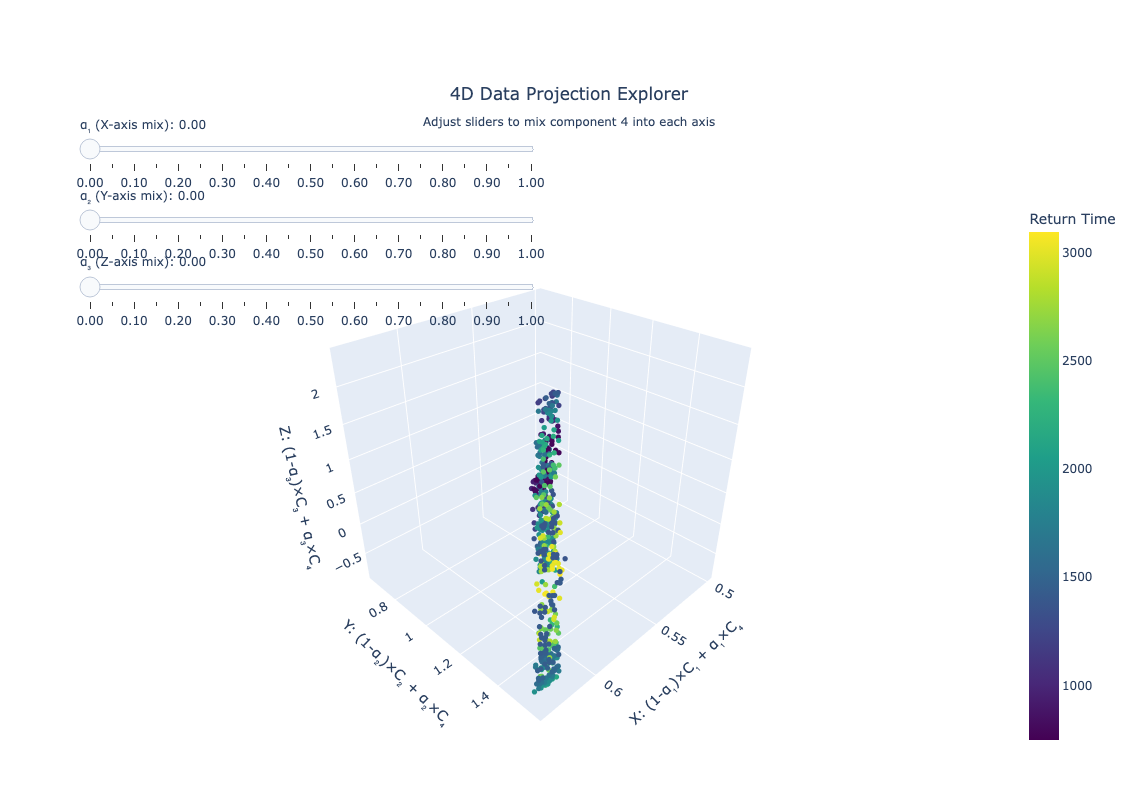

Interactive 4D projection explorer saved!

How to use:
- α=0: Shows original component on that axis
- α=1: Shows component 4 on that axis
- α∈(0,1): Linear interpolation between the two

Adjust the three sliders independently to explore different 3D projections of your 4D data.


In [37]:
import numpy as np
import plotly.graph_objects as go

# # Generate example 4D data (samples, 4)
# # Replace this with your actual data
# np.random.seed(42)
# n_samples = 500
# data = np.random.randn(n_samples, 4)

# # Add some structure to make it interesting
# t = np.linspace(0, 4*np.pi, n_samples)
# data[:, 0] = np.cos(t) + 0.3*np.random.randn(n_samples)
# data[:, 1] = np.sin(t) + 0.3*np.random.randn(n_samples)
# data[:, 2] = t/10 + 0.2*np.random.randn(n_samples)
# data[:, 3] = np.cos(2*t) + 0.3*np.random.randn(n_samples)

# Extract components
c1, c2, c3, c4 = ddata[:, 0], ddata[:, 1], ddata[:, 2], ddata[:, 3]

# Calculate return times (differences between consecutive samples)
# For Poincaré sections, this would be the time between successive crossings
# Creating variable return times for demonstration
# Replace this with: return_times = np.diff(your_actual_time_array)
# base_interval = 0.1

# return_times = base_interval + 0.05 * np.sin(np.linspace(0, 4*np.pi, n_samples-1))

# This creates return times that vary smoothly, simulating regions of
# fast vs slow dynamics (shorter vs longer times between Poincaré crossings)

# For visualization, we'll use the first (n_samples-1) points
# and color them by their return time to the next point
c1_trimmed = c1[:-1]
c2_trimmed = c2[:-1]
c3_trimmed = c3[:-1]
c4_trimmed = c4[:-1]
n_points = len(c1_trimmed)

# Create frames for different slider combinations
n_steps = 21  # Number of steps for each slider (0.0 to 1.0 in steps of 0.05)
alphas = np.linspace(0, 1, n_steps)

# We'll create frames for each combination of the three sliders
# For efficiency, we'll pre-compute key combinations and use sliders to select them
frames = []
frame_data = []

# Generate a reasonable subset of combinations
# Full grid would be 21^3 = 9261 frames which is too many
# Instead, we'll use the sliders to update via traces
for i, a1 in enumerate(alphas):
    for j, a2 in enumerate(alphas):
        for k, a3 in enumerate(alphas):
            # Calculate projected values
            val_1 = (1 - a1) * c1 + a1 * c4
            val_2 = (1 - a2) * c2 + a2 * c4
            val_3 = (1 - a3) * c3 + a3 * c4
            
            frame_name = f"a1_{i}_a2_{j}_a3_{k}"
            frame_data.append({
                'name': frame_name,
                'x': val_1,
                'y': val_2,
                'z': val_3,
                'a1': a1,
                'a2': a2,
                'a3': a3
            })

# Create initial plot (a1=a2=a3=0, showing components 1,2,3)
initial_x = c1_trimmed
initial_y = c2_trimmed
initial_z = c3_trimmed

fig = go.Figure()

# Add the scatter trace
fig.add_trace(go.Scatter3d(
    x=initial_x,
    y=initial_y,
    z=initial_z,
    mode='markers',
    marker=dict(
        size=3,
        color=return_times,  # Color by return time
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="Return Time")
    ),
    name='4D Projection'
))

# Create slider steps for each of the three parameters
steps_a1 = []
steps_a2 = []
steps_a3 = []

# Generate all combinations for the sliders
for i, a1 in enumerate(alphas):
    val_1 = (1 - a1) * c1_trimmed + a1 * c4_trimmed
    steps_a1.append(dict(
        method="restyle",
        args=[{"x": [val_1]}, [0]],
        label=f"{a1:.2f}"
    ))

for j, a2 in enumerate(alphas):
    val_2 = (1 - a2) * c2_trimmed + a2 * c4_trimmed
    steps_a2.append(dict(
        method="restyle",
        args=[{"y": [val_2]}, [0]],
        label=f"{a2:.2f}"
    ))

for k, a3 in enumerate(alphas):
    val_3 = (1 - a3) * c3_trimmed + a3 * c4_trimmed
    steps_a3.append(dict(
        method="restyle",
        args=[{"z": [val_3]}, [0]],
        label=f"{a3:.2f}"
    ))

# Add sliders
sliders = [
    dict(
        active=0,
        yanchor="top",
        y=1.25,
        xanchor="left",
        x=0.0,
        currentvalue=dict(
            prefix="α₁ (X-axis mix): ",
            visible=True,
            xanchor="left"
        ),
        pad=dict(b=10, t=50),
        len=0.5,
        steps=steps_a1
    ),
    dict(
        active=0,
        yanchor="top",
        y=1.12,
        xanchor="left",
        x=0.0,
        currentvalue=dict(
            prefix="α₂ (Y-axis mix): ",
            visible=True,
            xanchor="left"
        ),
        pad=dict(b=10, t=50),
        len=0.5,
        steps=steps_a2
    ),
    dict(
        active=0,
        yanchor="top",
        y=1.0,
        xanchor="left",
        x=0.0,
        currentvalue=dict(
            prefix="α₃ (Z-axis mix): ",
            visible=True,
            xanchor="left"
        ),
        pad=dict(b=10, t=50),
        len=0.5,
        steps=steps_a3
    )
]

fig.update_layout(
    sliders=sliders,
    scene=dict(
        xaxis_title='X: (1-α₁)×C₁ + α₁×C₄',
        yaxis_title='Y: (1-α₂)×C₂ + α₂×C₄',
        zaxis_title='Z: (1-α₃)×C₃ + α₃×C₄',
        camera=dict(
            eye=dict(x=1.5, y=1.5, z=1.3)
        )
    ),
    title=dict(
        text='4D Data Projection Explorer<br><sub>Adjust sliders to mix component 4 into each axis</sub>',
        x=0.5,
        xanchor='center'
    ),
    height=800,
    margin=dict(t=200, b=50)
)

fig.show()

# Save to HTML
# fig.write_html('4d_projection_explorer.html')

print("Interactive 4D projection explorer saved!")
print("\nHow to use:")
print("- α=0: Shows original component on that axis")
print("- α=1: Shows component 4 on that axis")
print("- α∈(0,1): Linear interpolation between the two")
print("\nAdjust the three sliders independently to explore different 3D projections of your 4D data.")

# 2D Bifurcations

In [137]:
import numpy as np
from scipy.integrate import solve_ivp
import sk_dsp_comm.sigsys as ss
import matplotlib.pyplot as plt

def sigmoid(u):
    return np.tanh(u)

def two_oscillators(t, y, h_ex, h_in, pars, frac_E, frac_I, sr, time_stop, pert):
    tau_ex, tau_in, c2, c4, c_EE, c_EI = pars
    time_index = int(t*sr)
    if time_index >= time_stop*sr:
        dydt = np.zeros(4)
        return dydt
    else:
        dydt = (
            (pert[time_index] - y[0] - c2*sigmoid(y[1]) + c_EE*sigmoid(y[0]+frac_E*y[2]))*tau_ex,
            (h_in             - y[1] - c4*sigmoid(y[1]) + c_EI*sigmoid(y[0]+frac_I*y[2]))*tau_in,
            (h_ex             - y[2] - c2*sigmoid(y[3]) + c_EE*sigmoid(y[2]+frac_E*y[0]))*tau_ex,
            (h_in             - y[3] - c4*sigmoid(y[3]) + c_EI*sigmoid(y[2]+frac_I*y[0]))*tau_in
        )
    return dydt

# Fixed parameters
h_ex_0 = -7.0
h_in_0 = -4.0
pars = (1, 2.5, 10, 0, 5, 10)  # Homoclinic
frac_E, frac_I = 0.2, 0.
y_ini = [-1.9, -13.56, -1.9, -13.56]
time_stop = 150
sr = 1000
time = np.linspace(start=0, stop=time_stop, num=time_stop*sr)
pulse_wid = 4.

# Parameter ranges for bifurcation diagram
pulse_amp_range = np.linspace(0.5, 3.5, 15)  # Adjust resolution as needed
pulse_per_range = np.linspace(0.5, 7, 15)  # Adjust resolution as needed

# Initialize bifurcation diagram matrix
bifurcation_matrix = np.zeros((len(pulse_per_range), len(pulse_amp_range)))

# Analysis time window (final third: t = 100 to 150)
analysis_start_idx = int(100 * sr)
analysis_end_idx   = int(150 * sr)

print("Starting bifurcation analysis...")
print(f"Scanning {len(pulse_amp_range)} x {len(pulse_per_range)} = {len(pulse_amp_range)*len(pulse_per_range)} parameter combinations")

# Scan parameter space
for i, pulse_per in enumerate(pulse_per_range):
    for j, pulse_amp in enumerate(pulse_amp_range):
        
        # Generate perturbation signal
        pert = h_ex_0 + pulse_amp*ss.rect(
            np.mod(time, pulse_per) - (pulse_per)/2 + pulse_wid/2, pulse_wid
        )
        
        # Run simulation
        try:
            solution = solve_ivp(
                fun=two_oscillators, 
                t_span=(0, time_stop), 
                y0=y_ini, 
                t_eval=time,
                args=(h_ex_0, h_in_0, pars, frac_E, frac_I, sr, time_stop, pert), 
                method='BDF', 
                max_step=0.1
            )
            
            y_pert = solution.y.T
            
            # Analyze final third (t = 100 to 150)
            y_analysis = y_pert[analysis_start_idx:analysis_end_idx, 2]
            
            # Check if any values exceed 0.5
            if np.any(y_analysis > 0.5):
                bifurcation_matrix[i, j] = 1  # Mark as active
            else:
                bifurcation_matrix[i, j] = 0  # Leave blank (inactive)
                
        except Exception as e:
            print(f"Error at pulse_amp={pulse_amp:.2f}, pulse_per={pulse_per:.2f}: {e}")
            bifurcation_matrix[i, j] = np.nan
    
    # Progress indicator
    if (i+1) % 5 == 0:
        print(f"Progress: {i+1}/{len(pulse_per_range)} rows completed")

print("Bifurcation analysis complete!")


Starting bifurcation analysis...
Scanning 15 x 15 = 225 parameter combinations
Progress: 5/15 rows completed
Progress: 10/15 rows completed
Progress: 15/15 rows completed
Bifurcation analysis complete!


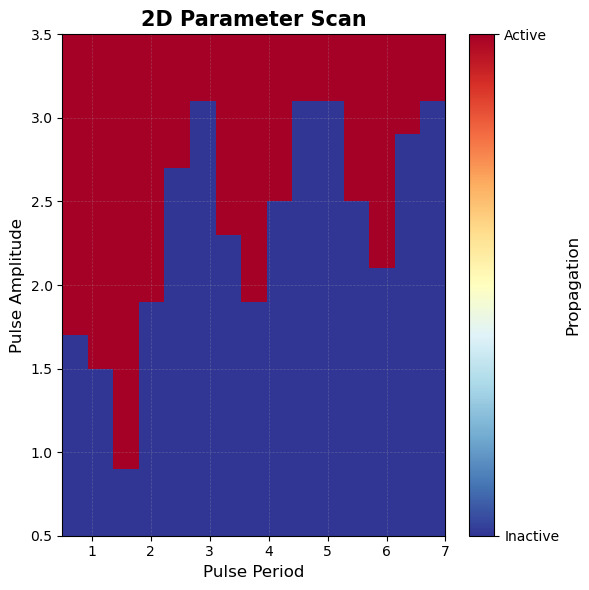

In [138]:
# Create bifurcation diagram
fig, ax = plt.subplots(figsize=(6, 6))

# Plot as heatmap
im = ax.imshow(
    bifurcation_matrix.T, 
    aspect='auto',
    origin='lower',
    extent=[pulse_per_range[0], pulse_per_range[-1],
            pulse_amp_range[0], pulse_amp_range[-1]],
    cmap='RdYlBu_r',
    interpolation='nearest'
)

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Propagation', fontsize=12)
cbar.set_ticks([0, 1])
cbar.set_ticklabels(['Inactive', 'Active'])

# Labels and title
ax.set_ylabel('Pulse Amplitude', fontsize=12)
ax.set_xlabel('Pulse Period', fontsize=12)
ax.set_title('2D Parameter Scan',
# \n(Analysis window: t = 100-150)', 
             fontsize=15, fontweight='bold')

# Grid
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

## Optional: Save data
# np.savez('bifurcation_data.npz', 
#          bifurcation_matrix=bifurcation_matrix,
#          pulse_amp_range=pulse_amp_range,
#          pulse_per_range=pulse_per_range)
# print("\nBifurcation data saved to 'bifurcation_data.npz'")


In [148]:
1/3.5, 1/6

(0.2857142857142857, 0.16666666666666666)

In [120]:
y_ini

array([ -1.89530054, -13.55833325,  -1.89530054, -13.55833325])

# Frequency Scan

In [31]:
# Bifurcation parameter set
steps = 50

par_min, par_max = 1, 10
# par_min, par_max = 4, 2

par_set = linspace(par_min, par_max, steps)

pulse_wid = 4.
pulse_amp = 0.44


# Time array
time_stop = 150
time = linspace(start=0, stop=time_stop, num=time_stop*sr)

results_min_f      = dict()
results_min_inds_f = dict()
results_max_f      = dict()
results_max_inds_f = dict()

rows = time.size

series_all = list()

# Simulation "forward"
for par in par_set:

    pert = h_ex_0 - pulse_amp*ss.rect(mod(time, par)-(par)/2+pulse_wid/2, pulse_wid)
  
    solution = solve_ivp(fun=two_oscillators, t_span=(0, time_stop), y0=y_ini, t_eval=time,
              args=(h_ex_0, h_in_0, pars, frac_E, frac_I, sr, time_stop, pert), 
              method='BDF', max_step=0.1)

    t, y_pert = solution.t, solution.y.T

    for num, series in enumerate(y_pert[2*rows//3 - int(pulse_wid*sr):,:-1:2].T):

        series_all.append(series)
                
        if var(series) < 0.001:
    
            if num not in results_min_f:
                
                results_min_f[num]      = [series[-1]]
                results_min_inds_f[num] = [0]    
               
            else:
                results_min_f[num].append(series[-1])
                results_min_inds_f[num].append(0)    

            if num not in results_max_f:
                
                results_max_f[num]      = [series[-1]]
                results_max_inds_f[num] = [0]    
               
            else:
                results_max_f[num].append(series[-1])
                results_max_inds_f[num].append(0)    

        else:
            
            y_f_max_inds = find_peaks(series, distance=100)
            y_f_maxs     = series[y_f_max_inds[0]]

            y_f_min_inds = find_peaks(-series, distance=100)
            y_f_mins     = series[y_f_min_inds[0]]

            if num not in results_min_f:

                results_min_f[num]      = [y_f_mins]
                results_min_inds_f[num] = [y_f_min_inds]
                
                results_max_f[num]      = [y_f_maxs]
                results_max_inds_f[num] = [y_f_max_inds]

            else:

                results_min_f[num].append(y_f_mins)
                results_min_inds_f[num].append(y_f_min_inds)
                
                results_max_f[num].append(y_f_maxs)
                results_max_inds_f[num].append(y_f_max_inds)


    # if par != par_set[-1]:
        
        # y_ini = y_pert[-1, :]
        
series_all = asarray(series_all)

print('')
print('Scan complete!', list(series_all.shape))
print('')


Scan complete! [100, 54000]



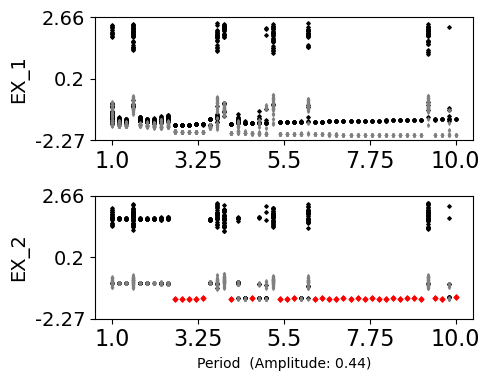

In [32]:
fig, ax = plot_bifdiagram(results_min_f, results_max_f, par_set)

ax[1].set_xlabel(f'Period  (Amplitude: {pulse_amp})', fontsize=10);

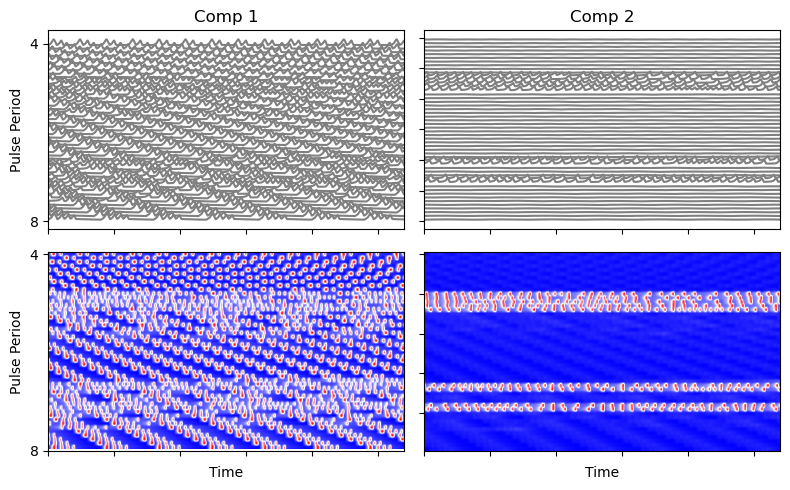

In [105]:
series_Ex1, series_Ex2 = series_all[:-1:2, :], series_all[1::2, :]

fig, ax = subplots(nrows=2, ncols=2, figsize=(8, 5))

ax[0, 0].plot  (series_Ex1.T - 3*arange(series_Ex1.shape[0]), color='gray');
ax[0, 0].set_title('Comp 1')
ax[0, 0].set_xticklabels([])
ax[0, 0].set_yticks([0, -150])
ax[0, 0].set_yticklabels([str(par_min), str(par_max)])
ax[0, 0].set_ylabel('Pulse Period')

ax[0, 1].plot  (series_Ex2.T - 3*arange(series_Ex1.shape[0]), color='gray');
ax[0, 1].set_title('Comp 2')
ax[0, 1].set_xticklabels([])
ax[0, 1].set_yticklabels([])

ax[1, 0].imshow(series_Ex1, aspect='auto', cmap='bwr');
ax[1, 0].set_xticklabels([])
ax[1, 0].set_yticks([0, 50])
ax[1, 0].set_yticklabels([str(par_min), str(par_max)])
ax[1, 0].set_xlabel('Time')
ax[1, 0].set_ylabel('Pulse Period')

ax[1, 1].imshow(series_Ex2, aspect='auto', cmap='bwr');
ax[1, 1].set_xticklabels([])
ax[1, 1].set_yticklabels([])
ax[1, 1].set_xlabel('Time')


ax[0, 0].margins(x=0)
ax[0, 1].margins(x=0)

fig.tight_layout()

# Bifurcation Diagram

In [68]:
# Bifurcation parameter set
steps = 30

par_min, par_max = -6.5, -6.8
# par_min, par_max = -6.8, -6.5

par_set = linspace(par_min, par_max, steps)

# Time array
time_stop = 500
time = linspace(start=0, stop=time_stop, num=time_stop*sr)

pert = h_ex_0 + pulse_amp*ss.rect(mod(time, pulse_per)-(pulse_per)/2+pulse_wid/2, pulse_wid)


results_min_f      = dict()
results_min_inds_f = dict()
results_max_f      = dict()
results_max_inds_f = dict()

rows = time.size

# pulse = []

# Simulation "forward"
for par in par_set:
      
    y_pert = odeint(func=oscillator, y0=y_ini, t=time, 
                  args=(par, h_in_0, pars, frac_E, frac_I, sr, time_stop, pert), 
                  hmax=0.1)

    for num, series in enumerate(y_pert[rows//2:,:-1:2].T):
                
        if var(series) < 0.0001:
    
            if num not in results_min_f:
                
                results_min_f[num]      = [series[-1]]
                results_min_inds_f[num] = [0]    
               
            else:
                results_min_f[num].append(series[-1])
                results_min_inds_f[num].append(0)    

            if num not in results_max_f:
                
                results_max_f[num]      = [series[-1]]
                results_max_inds_f[num] = [0]    
               
            else:
                results_max_f[num].append(series[-1])
                results_max_inds_f[num].append(0)    

        else:
            
            y_f_max_inds = find_peaks(series, distance=100)
            y_f_maxs     = series[y_f_max_inds[0]]

            y_f_min_inds = find_peaks(-series, distance=100)
            y_f_mins     = series[y_f_min_inds[0]]

            if num not in results_min_f:

                results_min_f[num]      = [y_f_mins]
                results_min_inds_f[num] = [y_f_min_inds]
                
                results_max_f[num]      = [y_f_maxs]
                results_max_inds_f[num] = [y_f_max_inds]

            else:

                results_min_f[num].append(y_f_mins)
                results_min_inds_f[num].append(y_f_min_inds)
                
                results_max_f[num].append(y_f_maxs)
                results_max_inds_f[num].append(y_f_max_inds)


    if par != par_set[-1]:
        
        y_ini = y_pert[-1, :]

print('')
print('Scan complete!', list(around(y_pert[-1,:],3)))
print('')


Scan complete! [np.float64(-1.664), np.float64(-13.491), np.float64(-1.591), np.float64(-13.422)]



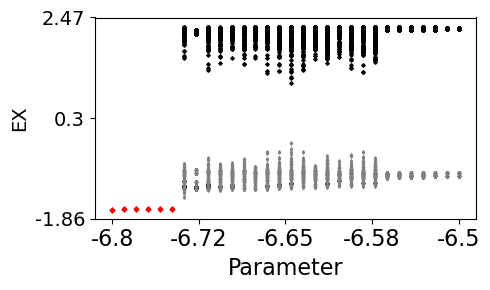

In [69]:
fig, ax = plot_bifdiagram(results_min_f, results_max_f, par_set)


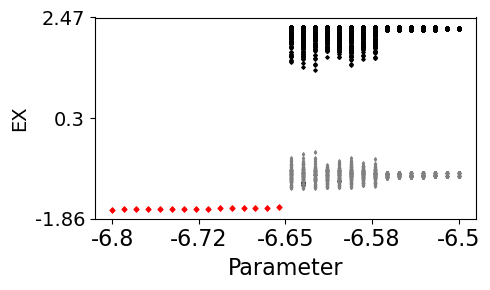

In [67]:
fig, ax = plot_bifdiagram(results_min_f, results_max_f, par_set)


# Distance Metrics

In [128]:
import numpy as np
from scipy.spatial.distance import euclidean

def path_length(trajectory):
    """Calculate the total path length of a trajectory"""
    displacements = np.linalg.norm(np.diff(trajectory, axis=0), axis=1)
    return np.sum(displacements)

def trajectory_difference_path_based(trajectory_data):
    """
    Compare trajectories based on their actual path characteristics
    """
    osc1_traj = trajectory_data[:, :2]
    osc2_traj = trajectory_data[:, 2:]
    
    # 1. Path length difference
    path1_length = path_length(osc1_traj)
    path2_length = path_length(osc2_traj)
    path_length_diff = abs(path1_length - path2_length)
    
    # 2. Area between paths (integrated distance)
    distances = np.linalg.norm(osc1_traj - osc2_traj, axis=1)
    area_between = np.trapz(distances, dx=1)
    
    # 3. Dynamic differences (velocity/orientation)
    vel1 = np.diff(osc1_traj, axis=0)
    vel2 = np.diff(osc2_traj, axis=0)
    
    # Cosine similarity of velocities (how aligned are movements)
    dot_products = np.sum(vel1 * vel2, axis=1)
    norms_product = np.linalg.norm(vel1, axis=1) * np.linalg.norm(vel2, axis=1)
    cosine_similarities = dot_products / (norms_product + 1e-10)  # avoid division by zero
    avg_alignment = np.mean(cosine_similarities)
    
    return {
        'path_length_difference': path_length_diff,
        'area_between_paths': area_between,
        'velocity_alignment': avg_alignment,
        'composite_measure': path_length_diff + area_between + (1 - avg_alignment)
    }

def dtw_distance(a, b):
    """Simple DTW implementation"""
    n, m = len(a), len(b)
    dtw_matrix = np.zeros((n+1, m+1))
    dtw_matrix[0, 1:] = np.inf
    dtw_matrix[1:, 0] = np.inf
    
    for i in range(1, n+1):
        for j in range(1, m+1):
            cost = abs(a[i-1] - b[j-1])
            dtw_matrix[i, j] = cost + min(dtw_matrix[i-1, j],    # insertion
                                         dtw_matrix[i, j-1],    # deletion  
                                         dtw_matrix[i-1, j-1])  # match
    
    return dtw_matrix[n, m]

def trajectory_difference_dtw(trajectory_data):
    """
    Use DTW to handle trajectories that are similar but phase-shifted
    """
    osc1_traj = trajectory_data[:, :2]
    osc2_traj = trajectory_data[:, 2:]
    
    # Apply DTW to each dimension separately
    dtw_x = dtw_distance(osc1_traj[:, 0], osc2_traj[:, 0])
    dtw_y = dtw_distance(osc1_traj[:, 1], osc2_traj[:, 1])
    
    # Combined DTW distance
    combined_dtw = np.sqrt(dtw_x**2 + dtw_y**2)
    
    return combined_dtw

def trajectory_shape_difference(trajectory_data):
    """
    Compare the shape characteristics of trajectories
    """
    osc1_traj = trajectory_data[:, :2]
    osc2_traj = trajectory_data[:, 2:]
    
    # Calculate curvature for each trajectory
    def calculate_curvature(traj):
        dx_dt = np.gradient(traj[:, 0])
        dy_dt = np.gradient(traj[:, 1])
        d2x_dt2 = np.gradient(dx_dt)
        d2y_dt2 = np.gradient(dy_dt)
        
        curvature = np.abs(dx_dt * d2y_dt2 - dy_dt * d2x_dt2) / (dx_dt**2 + dy_dt**2 + 1e-10)**1.5
        return curvature
    
    curvature1 = calculate_curvature(osc1_traj)
    curvature2 = calculate_curvature(osc2_traj)
    
    # Compare curvature profiles
    curvature_diff = np.mean(np.abs(curvature1 - curvature2))
    
    # Compare turning points (local maxima in curvature)
    from scipy.signal import find_peaks
    peaks1, _ = find_peaks(curvature1, height=np.mean(curvature1))
    peaks2, _ = find_peaks(curvature2, height=np.mean(curvature2))
    
    turning_point_diff = abs(len(peaks1) - len(peaks2))
    
    return curvature_diff + turning_point_diff

def comprehensive_trajectory_analysis(trajectory_data):
    """
    Comprehensive analysis that should distinguish different path types
    """
    osc1_traj = trajectory_data[:, :2]
    osc2_traj = trajectory_data[:, 2:]
    
    results = {}
    
    # Basic point-wise distances (your original approach)
    point_distances = np.linalg.norm(osc1_traj - osc2_traj, axis=1)
    results['max_point_distance'] = np.max(point_distances)
    results['mean_point_distance'] = np.mean(point_distances)
    results['area_between'] = np.trapezoid(point_distances, dx=1)
    
    # Path-based measures
    results['path_length_osc1'] = path_length(osc1_traj)
    results['path_length_osc2'] = path_length(osc2_traj)
    results['path_length_difference'] = abs(results['path_length_osc1'] - results['path_length_osc2'])
    
    # Dynamic measures
    vel1 = np.diff(osc1_traj, axis=0)
    vel2 = np.diff(osc2_traj, axis=0)
    
    velocity_correlations = []
    for i in range(len(vel1)):
        if np.linalg.norm(vel1[i]) > 0 and np.linalg.norm(vel2[i]) > 0:
            cos_sim = np.dot(vel1[i], vel2[i]) / (np.linalg.norm(vel1[i]) * np.linalg.norm(vel2[i]))
            velocity_correlations.append(cos_sim)
    
    results['velocity_correlation'] = np.mean(velocity_correlations) if velocity_correlations else 0
    
    # Shape-based measure
    results['shape_difference'] = trajectory_shape_difference(trajectory_data)
    
    # Create a single composite score
    results['composite_score'] = (
        results['area_between'] + 
        results['path_length_difference'] + 
        (1 - results['velocity_correlation']) +
        results['shape_difference']
    )
    
    return results


result_similar = comprehensive_trajectory_analysis(y_similar[105000:120000, :])

result_different = comprehensive_trajectory_analysis(y_different[105000:120000, :])

result_medium = comprehensive_trajectory_analysis(y_medium[105000:120000, :])

print("Similar trajectories:", result_similar['composite_score'])
print("Different trajectories:", result_different['composite_score'])
print("Medium trajectories:", result_medium['composite_score'])


Similar trajectories: 8624.300107775958
Different trajectories: 24771.765353695973
Medium trajectories: 54975.10050609993


In [118]:
result_similar

{'max_point_distance': np.float64(5.289331091709366),
 'mean_point_distance': np.float64(0.5749351955355837),
 'area_between': np.float64(8622.315682854667),
 'path_length_osc1': np.float64(36.908308037977434),
 'path_length_osc2': np.float64(35.12698331057021),
 'path_length_difference': np.float64(1.781324727407224),
 'velocity_correlation': np.float64(0.9730216308729599),
 'shape_difference': np.float64(0.17612182475539645),
 'composite_score': np.float64(8624.300107775958)}

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def extract_measures(trajectory_data):
    """
    Extract the three measures from a trajectory
    """
    # Reuse the functions from our previous analysis
    results = comprehensive_trajectory_analysis(trajectory_data)
    
    max_dist = results['max_point_distance']
    path_diff = results['path_length_difference']
    shape_diff = results['shape_difference']
    
    return [max_dist, path_diff, shape_diff]

# Alternative: Individual functions if you want them separate
def max_point_distance(trajectory_data):
    osc1_traj = trajectory_data[:, :2]
    osc2_traj = trajectory_data[:, 2:]
    distances = np.linalg.norm(osc1_traj - osc2_traj, axis=1)
    return np.max(distances)

def path_length_difference(trajectory_data):
    osc1_traj = trajectory_data[:, :2]
    osc2_traj = trajectory_data[:, 2:]
    
    def path_length(traj):
        displacements = np.linalg.norm(np.diff(traj, axis=0), axis=1)
        return np.sum(displacements)
    
    path1 = path_length(osc1_traj)
    path2 = path_length(osc2_traj)
    return abs(path1 - path2)

def shape_difference(trajectory_data):
    osc1_traj = trajectory_data[:, :2]
    osc2_traj = trajectory_data[:, 2:]
    
    def calculate_curvature(traj):
        dx_dt = np.gradient(traj[:, 0])
        dy_dt = np.gradient(traj[:, 1])
        d2x_dt2 = np.gradient(dx_dt)
        d2y_dt2 = np.gradient(dy_dt)
        
        curvature = np.abs(dx_dt * d2y_dt2 - dy_dt * d2x_dt2) / (dx_dt**2 + dy_dt**2 + 1e-10)**1.5
        return curvature
    
    curvature1 = calculate_curvature(osc1_traj)
    curvature2 = calculate_curvature(osc2_traj)
    
    from scipy.signal import find_peaks
    peaks1, _ = find_peaks(curvature1, height=np.mean(curvature1))
    peaks2, _ = find_peaks(curvature2, height=np.mean(curvature2))
    
    curvature_diff = np.mean(np.abs(curvature1 - curvature2))
    turning_point_diff = abs(len(peaks1) - len(peaks2))
    
    return curvature_diff + turning_point_diff

def plot_3d_trajectory_clusters(trajectories, labels=None, colors=None):
    """
    Create a 3D scatter plot of trajectory measures
    
    Parameters:
    trajectories: list of numpy arrays, each shape (samples, 4)
    labels: optional list of labels for each trajectory
    colors: optional list of colors for each trajectory
    """
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # If no colors provided, use a colormap
    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(trajectories)))
    elif len(colors) != len(trajectories):
        colors = [colors[0]] * len(trajectories)  # Use first color for all
    
    # Collect all measures for axis limits
    all_measures = []
    
    for index, trajectory in enumerate(trajectories):
        # Calculate the three measures
        measures = [
            max_point_distance(trajectory),
            path_length_difference(trajectory), 
            shape_difference(trajectory)
        ]
        
        all_measures.append(measures)
        
        # Create label
        if labels is not None and index < len(labels):
            label = labels[index]
        else:
            label = f'Traj {index+1}'
        
        # Plot the point
        ax.scatter(*measures, 
                  c=[colors[index]], 
                  s=100, 
                  label=label,
                  alpha=0.7,
                  edgecolors='w',
                  linewidth=0.5)
    
    all_measures = np.array(all_measures)
    
    # Set labels and title
    ax.set_xlabel('Max Point Distance', fontsize=12, labelpad=10)
    ax.set_ylabel('Path Length Difference', fontsize=12, labelpad=10)
    ax.set_zlabel('Shape Difference', fontsize=12, labelpad=10)
    ax.set_title('3D Trajectory Clustering', fontsize=14, fontweight='bold', pad=20)
    
    # Add legend
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Adjust viewing angle for better visualization
    ax.view_init(elev=20, azim=45)
    
    plt.tight_layout()
    plt.show()
    
    return all_measures

# Enhanced version with clustering visualization
def plot_3d_trajectory_clusters_enhanced(trajectories, group_labels=None, cluster_colors=None):
    """
    Enhanced version with better grouping and visualization
    """
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Define colors for different groups
    if cluster_colors is None:
        cluster_colors = plt.cm.Set1(np.linspace(0, 1, len(set(group_labels)) if group_labels else 1))
    
    all_measures = []
    
    for index, trajectory in enumerate(trajectories):
        measures = [
            max_point_distance(trajectory),
            path_length_difference(trajectory), 
            shape_difference(trajectory)
        ]
        all_measures.append(measures)
        
        # Determine color and label based on grouping
        if group_labels and index < len(group_labels):
            group_idx = group_labels[index]
            color = cluster_colors[group_idx]
            label = f'Group {group_idx}' if index == 0 or group_labels[index-1] != group_idx else ""
        else:
            color = 'blue'
            label = f'Traj {index+1}'
        
        ax.scatter(*measures, 
                  c=[color], 
                  s=100, 
                  label=label,
                  alpha=0.7,
                  edgecolors='w',
                  linewidth=1)
    
    all_measures = np.array(all_measures)
    
    # Set labels with units if known
    ax.set_xlabel('Max Distance\n(larger = more separation)', fontsize=11, labelpad=10)
    ax.set_ylabel('Path Length Diff\n(larger = different path lengths)', fontsize=11, labelpad=10)
    ax.set_zlabel('Shape Difference\n(larger = different shapes)', fontsize=11, labelpad=10)
    ax.set_title('3D Trajectory Measure Space\n(Cluster Analysis)', fontsize=14, fontweight='bold', pad=20)
    
    # Add grid and improve layout
    ax.grid(True, alpha=0.3)
    
    # Remove duplicate labels in legend
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), 
              bbox_to_anchor=(1.15, 1), loc='upper left')
    
    # Multiple viewing angles
    print("Plotting from multiple angles...")
    angles = [(30, 45), (20, 135), (10, 225)]
    
    for i, (elev, azim) in enumerate(angles):
        ax.view_init(elev=elev, azim=azim)
        plt.draw()
        plt.pause(0.5)  # Brief pause to see different angles
    
    plt.tight_layout()
    plt.show()
    
    return all_measures

# Simple version following your pseudocode exactly
def simple_3d_plot(trajectory):
    """
    Simple version following your pseudocode exactly
    """
 
    for index, trajectory in enumerate(trajectories):
        measures = [
            max_point_distance(trajectory),
            path_length_difference(trajectory), 
            max_point_distance(trajectory)
        ]
        
        ax.scatter(*measures, s=80, alpha=0.7, label=f'Traj {index+1}')
    
    ax.set_xlabel('Max Point Distance')
    ax.set_ylabel('Path Length Difference')
    ax.set_zlabel('Shape Difference')
    ax.set_title('3D Trajectory Measures')
    ax.legend()
    
    plt.show()


# 3D Scatter of trajectories measures

In [8]:
# pulse_wid = 4.
# pulse_per = 200.

# # Time array
# time_stop = 200
# sr        = 1000
# time      = linspace(start=0, stop=time_stop, num=time_stop*sr)

# rows = time.size

# fig = plt.figure(figsize=(6, 6))

# ax = fig.add_subplot(projection='3d')

# pulse_amps = linspace(1, 8, 30)


# measures_all = list()

# for pulse_amp in pulse_amps:
    
#     pert = h_ex_0 + pulse_amp*ss.rect(mod(time, pulse_per)-(pulse_per)/2+pulse_wid/2, pulse_wid)

#     # Simulation
#     y_pert = odeint(func=oscillator, y0=y_ini, t=time, 
#                   args=(N, h_ex_0, h_in_0, pars, frac_E, frac_I, sr, time_stop, pert), 
#                   hmax=0.1)

#     trajectory = y_pert[105000:130000, :]
    
#     measures = [max_point_distance(trajectory), path_length_difference(trajectory), shape_difference(trajectory)]

#     measures_all.append(measures)


# param_min, param_max = np.min(pulse_amps), np.max(pulse_amps)
# param_norm = (pulse_amps - param_min) / (param_max - param_min)

# colormap = plt.get_cmap('spring')

# for ind, meas in enumerate(measures_all):
    
#     color = colormap(param_norm[ind])

#     scatter = ax.scatter(*meas, s=80, alpha=0.7, color=color)

# # Create colorbar with the correct colormap
# cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=colormap, 
#                                         norm=plt.Normalize(param_min, param_max)), 
#                    ax=ax, shrink=0.4, aspect=20, pad=0.1)
# cbar.set_label('Pulse Amplitude')


# ax.set_xlabel('Max Point Distance')
# ax.set_ylabel('Path Length Difference')
# ax.set_zlabel('Shape Difference')
# ax.set_title('3D Trajectory Measures')


# ax.view_init(50, 30)


In [9]:
# fig = plt.figure(figsize=(6, 6))

# ax = fig.add_subplot(projection='3d')

# for ind, meas in enumerate(measures_all):
    
#     color = colormap(param_norm[ind])

#     scatter = ax.scatter(*meas, s=80, alpha=0.7, color=color)

# # Create colorbar with the correct colormap
# cbar = fig.colorbar(plt.cm.ScalarMappable(cmap=colormap, 
#                                         norm=plt.Normalize(param_min, param_max)), 
#                    ax=ax, shrink=0.4, aspect=20, pad=0.1)
# cbar.set_label('Pulse Amplitude')


# ax.set_xlabel('Max Point Distance')
# ax.set_ylabel('Path Length Difference')
# ax.set_zlabel('Shape Difference')
# ax.set_title('3D Trajectory Measures')

# ax.view_init(20, 30)

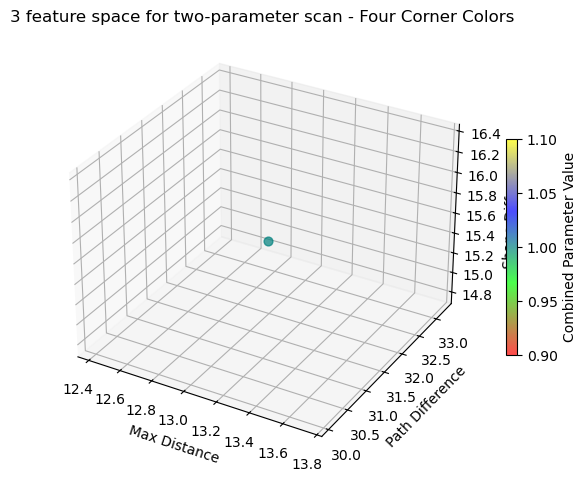

In [11]:
from matplotlib.colors import LinearSegmentedColormap

def create_2d_colormap():
    """Create a colormap that interpolates between four corners"""
    colors = [
        [1, 0, 0],  # Red - bottom-left
        [0, 1, 0],  # Green - bottom-right
        [0, 0, 1],  # Blue - top-left  
        [1, 1, 0],  # Yellow - top-right
    ]
    return LinearSegmentedColormap.from_list('four_corners', colors, N=256)



pulse_per = 200.

# Time array
time_stop = 200
sr        = 1000
time      = linspace(start=0, stop=time_stop, num=time_stop*sr)

rows = time.size


pulse_amps = linspace(2, 5, 40)
pulse_wids = linspace(2, 5, 40)


measures_all    = list()
combined_params = list()  # Store combined parameter values for coloring
color_values    = list()
osc_2_amps      = list()

for pulse_wid, pulse_amp in product(pulse_wids, pulse_amps):

    pert = h_ex_0 + pulse_amp*ss.rect(mod(time, pulse_per)-(pulse_per)/2+pulse_wid/2, pulse_wid)

    # Simulation
    y_pert = odeint(func=oscillator, y0=y_ini, t=time, 
                  args=(h_ex_0, h_in_0, pars, frac_E, frac_I, sr, time_stop, pert), 
                  hmax=0.1)

    trajectory = y_pert[100000:130000, :]

    osc_2_extr = trajectory[:, 2].max() - trajectory[:, 2].min()
    osc_2_amps.append(osc_2_extr)
    
    measures = [max_point_distance(trajectory), path_length_difference(trajectory), shape_difference(trajectory)]

    measures_all.   append(measures)
    combined_params.append(pulse_wid * pulse_amp) 

    # Create a combined value that captures both dimensions
    wid_norm = (pulse_wid - pulse_wids.min()) / (pulse_wids.max() - pulse_wids.min())
    amp_norm = (pulse_amp - pulse_amps.min()) / (pulse_amps.max() - pulse_amps.min())
    
    # This formula gives a smooth gradient across the 2D space
    combined_value = (wid_norm + amp_norm) / 2  # or try other combinations
    color_values.append(combined_value)


measures_array = np.array(measures_all)
# combined_params = np.array(combined_params)
color_values   = np.array(color_values)

mask = asarray(osc_2_amps) > 1

#################
# Plot
fig = plt.figure(figsize=(7, 7))
ax  = fig.add_subplot(111, projection='3d')

custom_cmap = create_2d_colormap()

scatter = ax.scatter(measures_array[mask, 0], measures_array[mask, 1], measures_array[mask, 2],
                    c=color_values[mask], cmap=custom_cmap, s=40, alpha=0.7)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.4)
cbar.set_label('Combined Parameter Value')

ax.set_xlabel('Max Distance')
ax.set_ylabel('Path Difference') 
ax.set_zlabel('Shape Difference')
ax.set_title('3 feature space for two-parameter scan - Four Corner Colors');


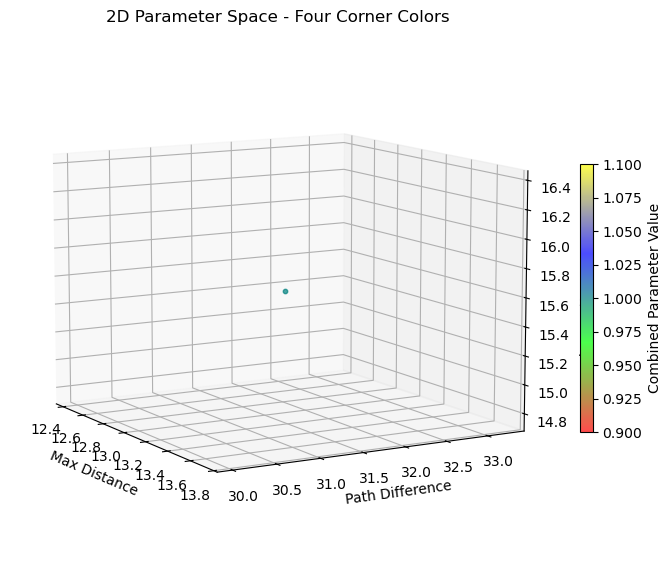

In [12]:
fig = plt.figure(figsize=(7, 7))
ax  = fig.add_subplot(111, projection='3d')

custom_cmap = create_2d_colormap()

mask = asarray(osc_2_amps) > 2

scatter = ax.scatter(measures_array[mask, 0], measures_array[mask, 1], measures_array[mask, 2],
                        c=asarray(color_values)[mask], cmap=custom_cmap, s=10, alpha=0.7)

cbar = plt.colorbar(scatter, ax=ax, shrink=0.4)
cbar.set_label('Combined Parameter Value')


ax.set_xlabel('Max Distance')
ax.set_ylabel('Path Difference') 
ax.set_zlabel('Shape Difference')
ax.set_title('2D Parameter Space - Four Corner Colors')

ax.view_init(10, -30)

fig.tight_layout()


# Plotly Version

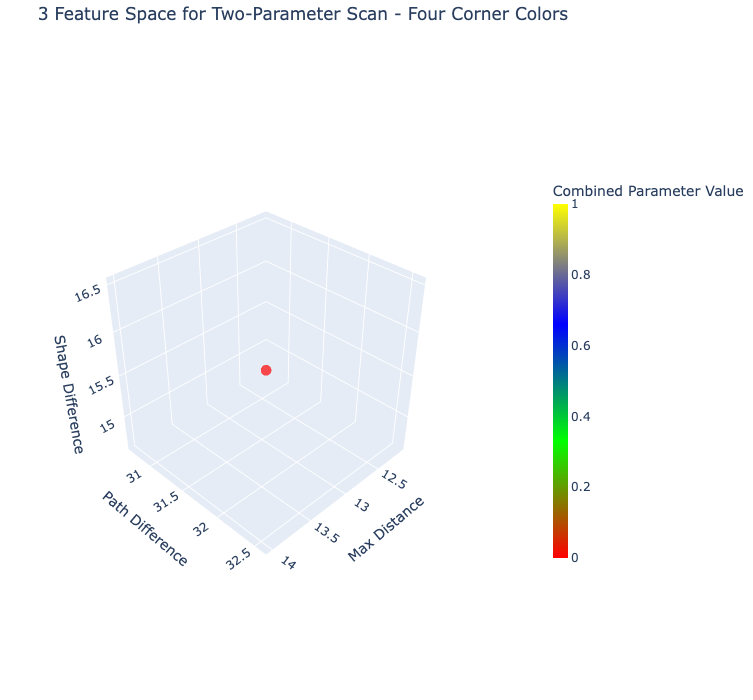

In [15]:
import plotly.graph_objects as go
import plotly.express as px
import numpy as np

# Convert your matplotlib colormap to Plotly
def create_plotly_colorscale(cmap_name='spring', n_colors=256):
    """Convert matplotlib colormap to Plotly colorscale"""
    cmap = plt.get_cmap(cmap_name)
    colorscale = []
    for i in range(n_colors):
        ratio = i / (n_colors - 1)
        rgb = cmap(ratio)
        colorscale.append([ratio, f'rgb({rgb[0]*255:.0f}, {rgb[1]*255:.0f}, {rgb[2]*255:.0f})'])
    return colorscale

# Create custom four-corner colorscale for Plotly
def create_four_corner_colorscale():
    """Create the same four-corner colorscale in Plotly"""
    return [
        [0.0, 'rgb(255, 0, 0)'],    # Red
        [0.33, 'rgb(0, 255, 0)'],   # Green
        [0.66, 'rgb(0, 0, 255)'],   # Blue
        [1.0, 'rgb(255, 255, 0)']   # Yellow
    ]

# Create the interactive Plotly figure
fig = go.Figure(data=[go.Scatter3d(
    x=measures_array[mask, 0],      # Max Distance
    y=measures_array[mask, 1],      # Path Difference
    z=measures_array[mask, 2],      # Shape Difference
    mode='markers',
    marker=dict(
        size=6,
        color=color_values,      # Combined Parameter Value
        colorscale=create_four_corner_colorscale(),  # Your custom colormap
        opacity=0.7,
        colorbar=dict(
            title='Combined Parameter Value',
            thickness=15,
            len=0.6
        )
    ),
    hovertemplate=(
        "<b>Max Distance:</b> %{x:.3f}<br>" +
        "<b>Path Difference:</b> %{y:.3f}<br>" +
        "<b>Shape Difference:</b> %{z:.3f}<br>" +
        "<b>Param Value:</b> %{marker.color:.3f}<br>" +
        "<extra></extra>"
    )
)])

# Update layout for better appearance
fig.update_layout(
    title='3 Feature Space for Two-Parameter Scan - Four Corner Colors',
    scene=dict(
        xaxis_title='Max Distance',
        yaxis_title='Path Difference',
        zaxis_title='Shape Difference',
        camera=dict(
            eye=dict(x=2.2, y=2.2, z=2.2)  # Initial camera position
        )
    ),
    width=700,
    height=700,
    margin=dict(l=0, r=0, b=0, t=40)
)

fig.show()

# Pulse Parameter Scan 2D

COMPLETE
 


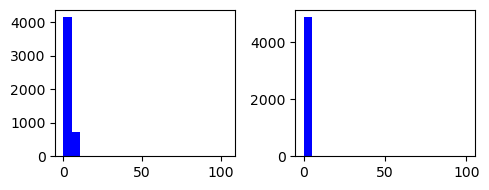

In [14]:
# Initial conditions y_last
y_last = y_ini.copy()

time_stop_pert = 200
sr             = 1000
time           = linspace(start=0, stop=time_stop_pert, num=time_stop_pert*sr)

resolution = 70

pulse_width_min, pulse_width_max = 0.1, 5.1
pulse_ampli_min, pulse_ampli_max = 5, 0.0001

pulse_width = linspace(pulse_width_min, pulse_width_max, resolution)
pulse_ampli = linspace(pulse_ampli_min, pulse_ampli_max, resolution)

pulse_period = 200

results_pert = list()

for pulse_wid, pulse_amp in product(pulse_width, pulse_ampli):

    h_ex_p = h_ex_0 + pulse_amp*ss.rect(mod(time, pulse_period)-pulse_period/2+pulse_wid/2, pulse_wid)

    y = odeint(func=oscillator, y0=y_last, t=time, args=(h_ex_0, h_in_0, pars, frac_E, frac_I, sr, time_stop_pert, h_ex_p),
              hmax=0.1)


    results_pert.append((sum(y[time_stop_pert*sr//2:, 0] - y_last[0])/sr, 
                         sum(y[time_stop_pert*sr//2:, 2] - y_last[2])/sr
                     ))

results_pert_ex1_matrix = asarray(results_pert)[:, 0].reshape(resolution, resolution)
results_pert_ex2_matrix = asarray(results_pert)[:, 1].reshape(resolution, resolution)

print('COMPLETE')
print(' ')

fig, ax = subplots(ncols=2, figsize=(5, 2))

ax[0].hist(results_pert_ex1_matrix.ravel(), bins=20, color='b');

ax[1].hist(results_pert_ex2_matrix.ravel(), bins=20, color='b');

fig.tight_layout()


'PulsePert_Homoclinic_frac_E=0.15_frac_I=0.0.png'

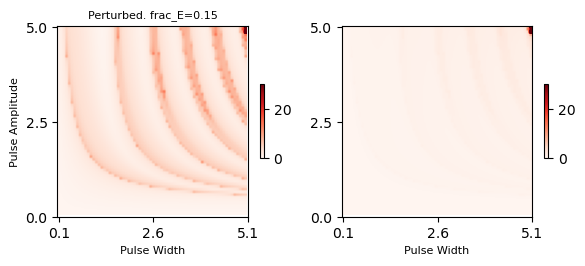

In [16]:
vmin1, vmax1 = 0, 30
vmin2, vmax2 = 0, 30

fig, ax = subplots(figsize=(6, 4), ncols=2)

im1 = ax[0].imshow(results_pert_ex1_matrix.T, cmap='Reds', vmin=vmin1, vmax=vmax1)

ax[0].set_xlabel('Pulse Width', fontsize=8)
ax[0].set_ylabel('Pulse Amplitude', fontsize=8)
ax[0].set_xticks(linspace(0, resolution, 3))
ax[0].set_xticklabels(around(linspace(pulse_width_min, pulse_width_max, 3),1))
ax[0].set_yticks(linspace(0, resolution, 3))
ax[0].set_yticklabels(around(linspace(pulse_ampli_min, pulse_ampli_max, 3), 2))
ax[0].set_title(f'Perturbed. frac_E={frac_E}', fontsize=8)



im2 = ax[1].imshow(results_pert_ex2_matrix.T, cmap='Reds', vmin=vmin2, vmax=vmax2)

ax[1].set_xlabel('Pulse Width', fontsize=8)
# ax[1].set_ylabel('Pulse Amplitude', fontsize=8)
ax[1].set_xticks(linspace(0, resolution, 3))
ax[1].set_xticklabels(around(linspace(pulse_width_min, pulse_width_max, 3), 1))
ax[1].set_yticks(linspace(0, resolution, 3))
ax[1].set_yticklabels(around(linspace(pulse_ampli_min, pulse_ampli_max, 3), 2))


fig.colorbar(im1, ax=ax[0], shrink=0.2);
fig.colorbar(im2, ax=ax[1], shrink=0.2);

fig.tight_layout()

if pars[1] == 1.5:
    
    title_chars = 'Figs/N=1/Fig_2Cb_PulsePert_SNIC.png'
    
elif pars[1] == 2.5:

    title_chars = 'PulsePert_Homoclinic_frac_E=' + str(frac_E) + '_frac_I=' + str(frac_I) +'.png'

# fig.savefig(title_chars, dpi=300, format='png', bbox_inches='tight')

title_chars

In [9]:
h_ex_0

-6.95